In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as sps
from scipy.stats import norm
from scipy.stats import expon
from scipy.stats import cauchy

sns.set(style='whitegrid', font_scale=1.3, palette='Set2')

---

Для $U[0, 1]$ сгенерируйте $200$ независимых случайных величин, постройте график плотности на отрезке $[-0.25, 1.25]$, а также гистограмму по сгенерированным случайным величинам. Для построения графика необходимо брать достаточно большое количество точек сетки.

In [40]:
def coin(size):
    return sps.bernoulli.rvs(p=0.5, size=size)

def uniform(size=1, precision=30):
    if isinstance(size, int):
        size = (size,)
    a = coin(size + (precision,))
    b = 2.0 ** -np.arange(1, precision + 1)
    x = (a * b).sum(axis=-1)

    return x

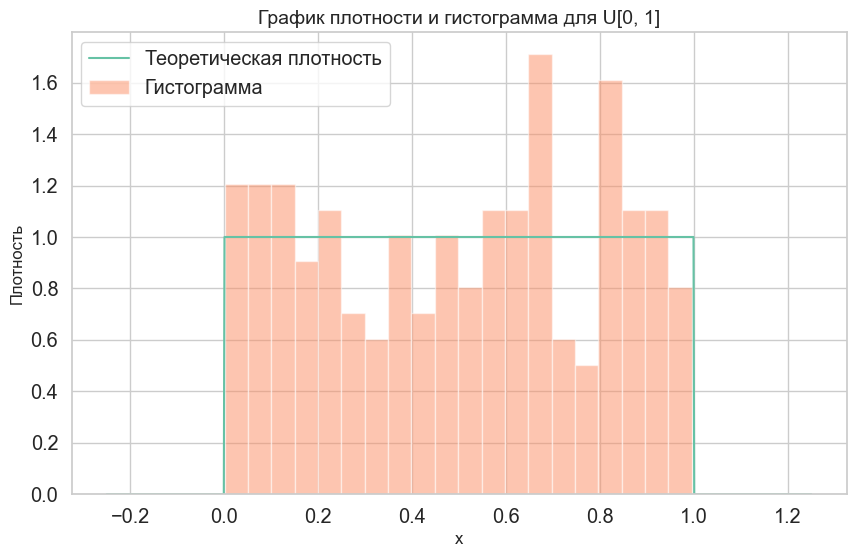

In [41]:
random_values = uniform(200)

x = np.linspace(-0.25, 1.25, 1000)
density = np.where((x >= 0) & (x <= 1), 1, 0)

plt.figure(figsize=(10, 6))
plt.plot(x, density, label='Теоретическая плотность')
plt.hist(random_values, bins=20, density=True, alpha=0.5, label='Гистограмма')

plt.title('График плотности и гистограмма для U[0, 1]', fontsize=14)
plt.xlabel('x', fontsize=12)
plt.ylabel('Плотность', fontsize=12)
plt.legend()
plt.grid(True)

plt.show()

Исследуйте, как меняются значения случайных величин в зависимости от `precision` в написанной ранее вами функции.

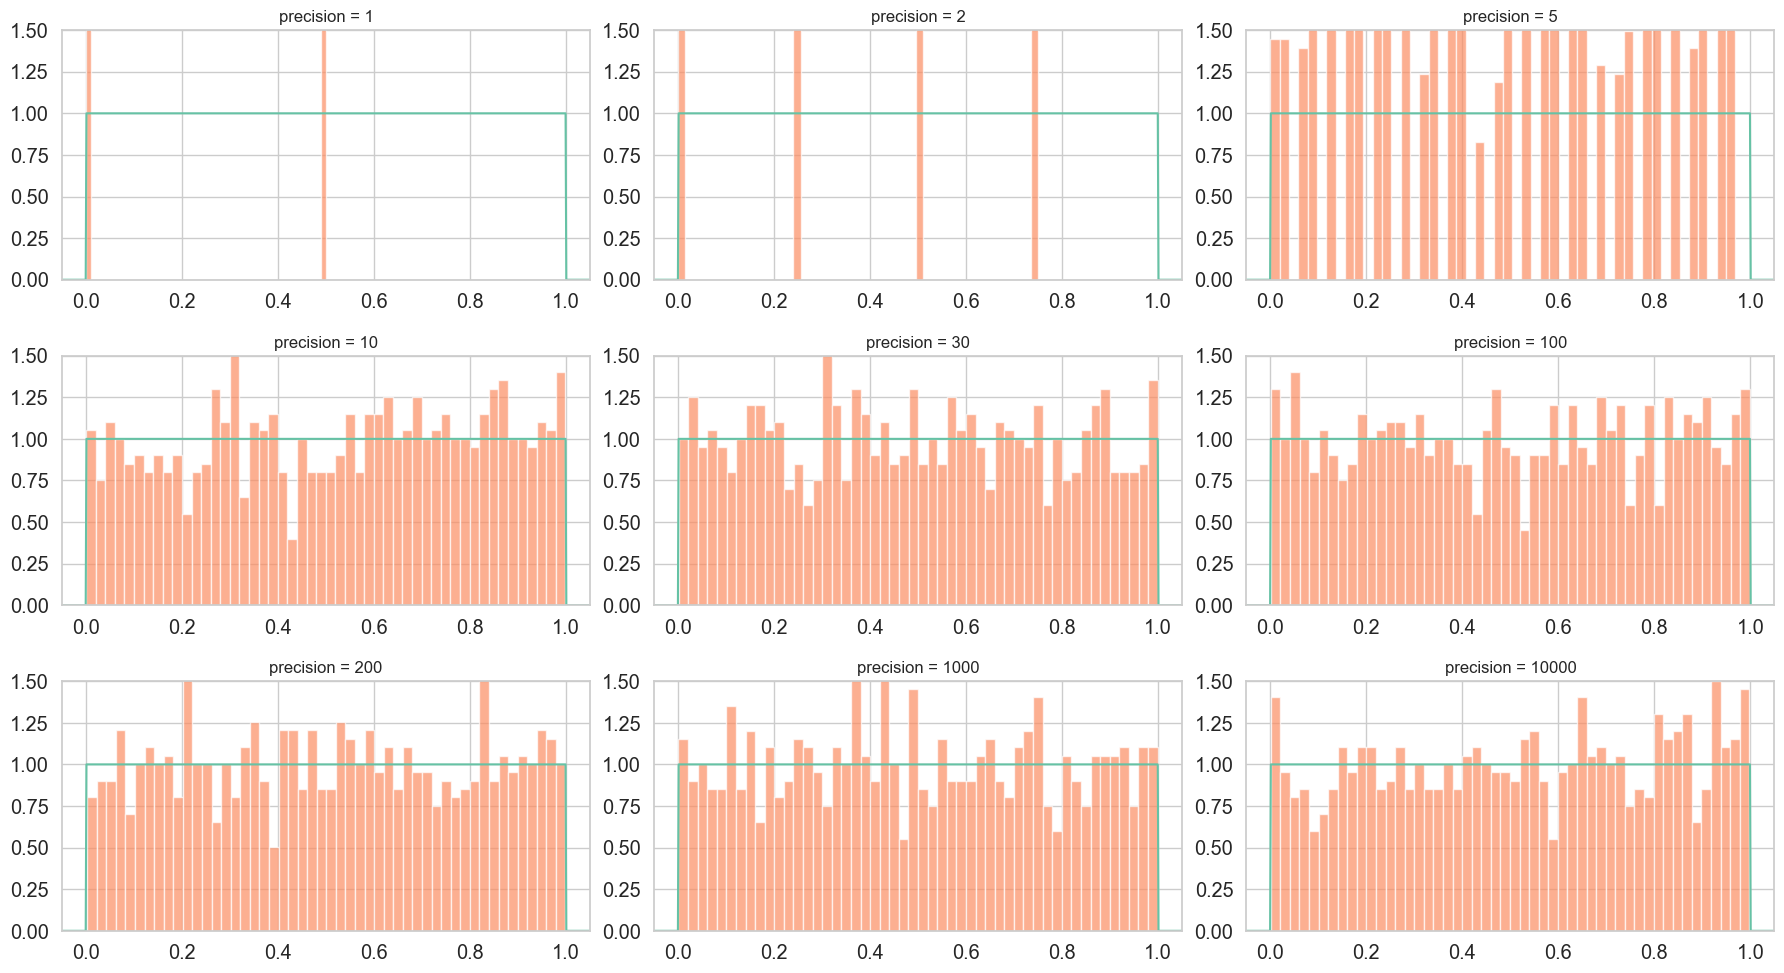

In [42]:
precisions = [1, 2, 5, 10, 30, 100, 200, 1000, 10000]
n_cols = 3
n_rows = 3

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 10))
axes = axes.flatten()

for i, p in enumerate(precisions):
    samples = uniform(size=1000, precision=p)
    ax = axes[i]
    ax.plot(x, density)
    ax.hist(samples, bins=50, density=True, alpha=0.7)
    ax.set_title(f'precision = {p}', fontsize=12)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(0, 1.5)
    ax.grid(True)

plt.tight_layout()
plt.show()

Для $\mathcal{N}(0, 1)$ сгенерируйте $200$ независимых случайных величин, постройте график плотности на отрезке $[-3, 3]$, а также гистограмму по сгенерированным случайным величинам.

In [43]:
def normal(size=1, loc=0, scale=1, precision=30):
    if isinstance(size, int):
        size = (size,)
    n = np.prod(size)
    p = (n + 1) // 2
    u = uniform(size=(2 * p,), precision=precision)
    u1 = u[:p]
    u2 = u[p:]
    r = np.sqrt(-2 * np.log(u1))
    x = 2 * np.pi * u2
    z1 = r * np.cos(x)
    z2 = r * np.sin(x)
    z = np.concatenate([z1, z2])[:n]

    return (loc + scale * z).reshape(size)

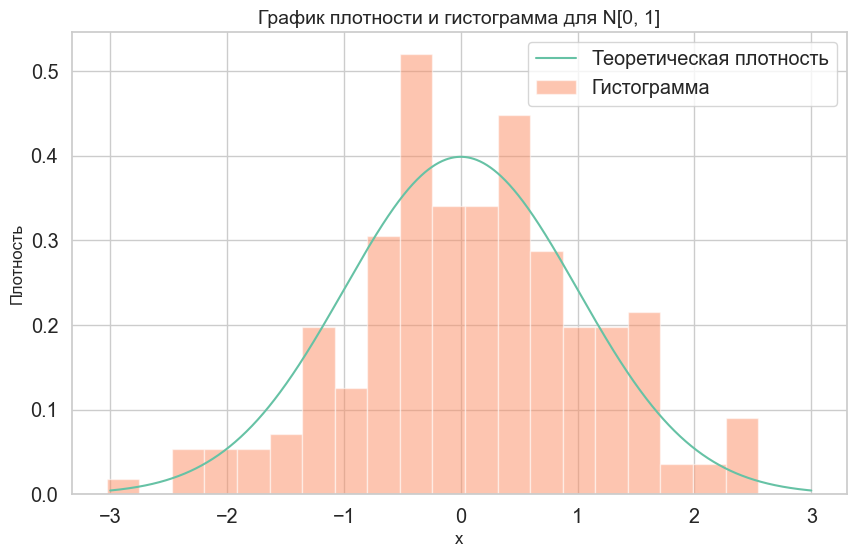

In [45]:
random_values = normal(size=200, loc=0, scale=1, precision=100)
x = np.linspace(-3, 3, 1000)
density = norm.pdf(x, loc=0, scale=1)

plt.figure(figsize=(10, 6))
plt.plot(x, density, label='Теоретическая плотность')
plt.hist(random_values, bins=20, density=True, alpha=0.5, label='Гистограмма')

plt.title('График плотности и гистограмма для N[0, 1]', fontsize=14)
plt.xlabel('x', fontsize=12)
plt.ylabel('Плотность', fontsize=12)
plt.legend()
plt.grid(True)


Для $Exp(1)$ сгенерируйте выборку размера 100 и постройте график плотности этого распределения на отрезке $[-0.5, 5]$.

In [46]:
def exp(size=1, lambd=1, precision=30):
    if isinstance(size, int):
        size = (size,)
    u = uniform(size=size, precision=precision)
    x = -np.log(u) / lambd

    return x

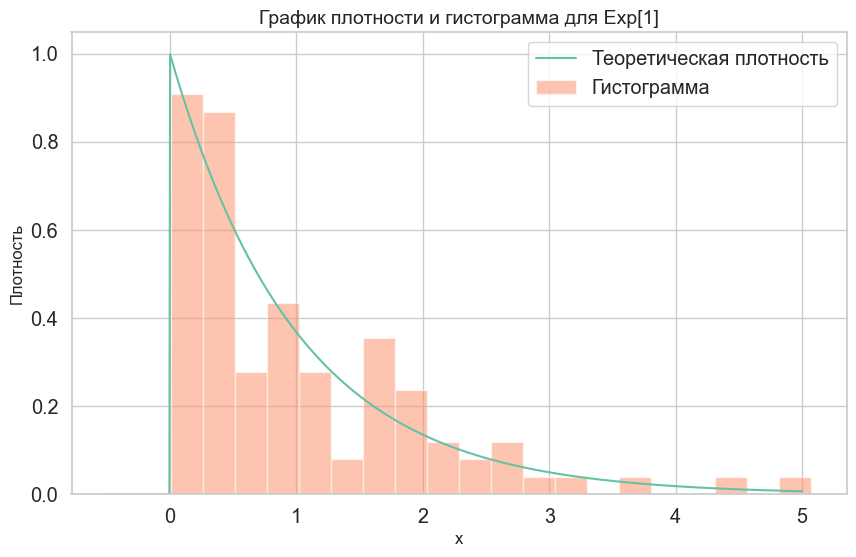

In [49]:
random_values = exp(size=100, lambd=1, precision=100)
x = np.linspace(-0.5, 5, 1000)
density = expon.pdf(x, scale=1)

plt.figure(figsize=(10, 6))
plt.plot(x, density, label='Теоретическая плотность')
plt.hist(random_values, bins=20, density=True, alpha=0.5, label='Гистограмма')
plt.title('График плотности и гистограмма для Exp[1]', fontsize=14)
plt.xlabel('x', fontsize=12)
plt.ylabel('Плотность', fontsize=12)
plt.legend()
plt.grid(True)

Если брать довольно маленькие precisionы, то распределения будут получаться плохие расределения. Но при $precision \geq 10$ в целом то насколько хорошо распределены с.в. не меняется особо. И для каждого из распределений в целов вид гистограмы похож на теоретическое распределение.

---

Рассмотрим распределение Коши</a> с плотностью.  
Повторите эксперимент с занятия про закон больших чисел для распределения Коши. 

**1.** Визуализируйте на одном графики плотности нормального распределения и распределения Коши. Что можно сказать?

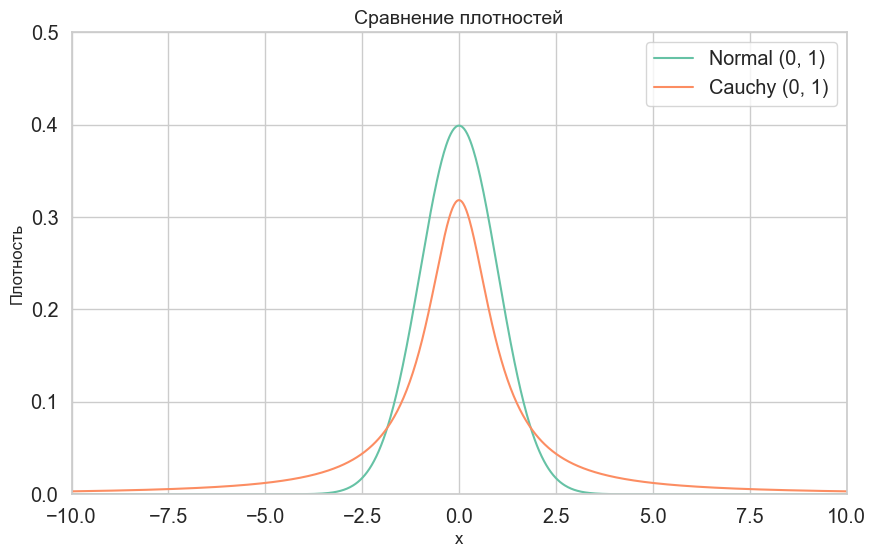

In [52]:
x = np.linspace(-10, 10, 1000)

normal_pdf = norm.pdf(x, loc=0, scale=1)
cauchy_pdf = cauchy.pdf(x, loc=0, scale=1)

plt.figure(figsize=(10, 6))
plt.plot(x, normal_pdf, label='Normal (0, 1)')
plt.plot(x, cauchy_pdf, label='Cauchy (0, 1)')

plt.title('Сравнение плотностей', fontsize=14)
plt.xlabel('x', fontsize=12)
plt.ylabel('Плотность', fontsize=12)
plt.legend()
plt.grid(True)
plt.ylim(0, 0.5)
plt.xlim(-10, 10)
plt.show()

Обе плотности симметричные и имеют примерно одинаковую форму, но плотность распределения Коши убывает сильно медленнее чем нормальное.

Выполняется ли ЗБЧ для распределения Коши?

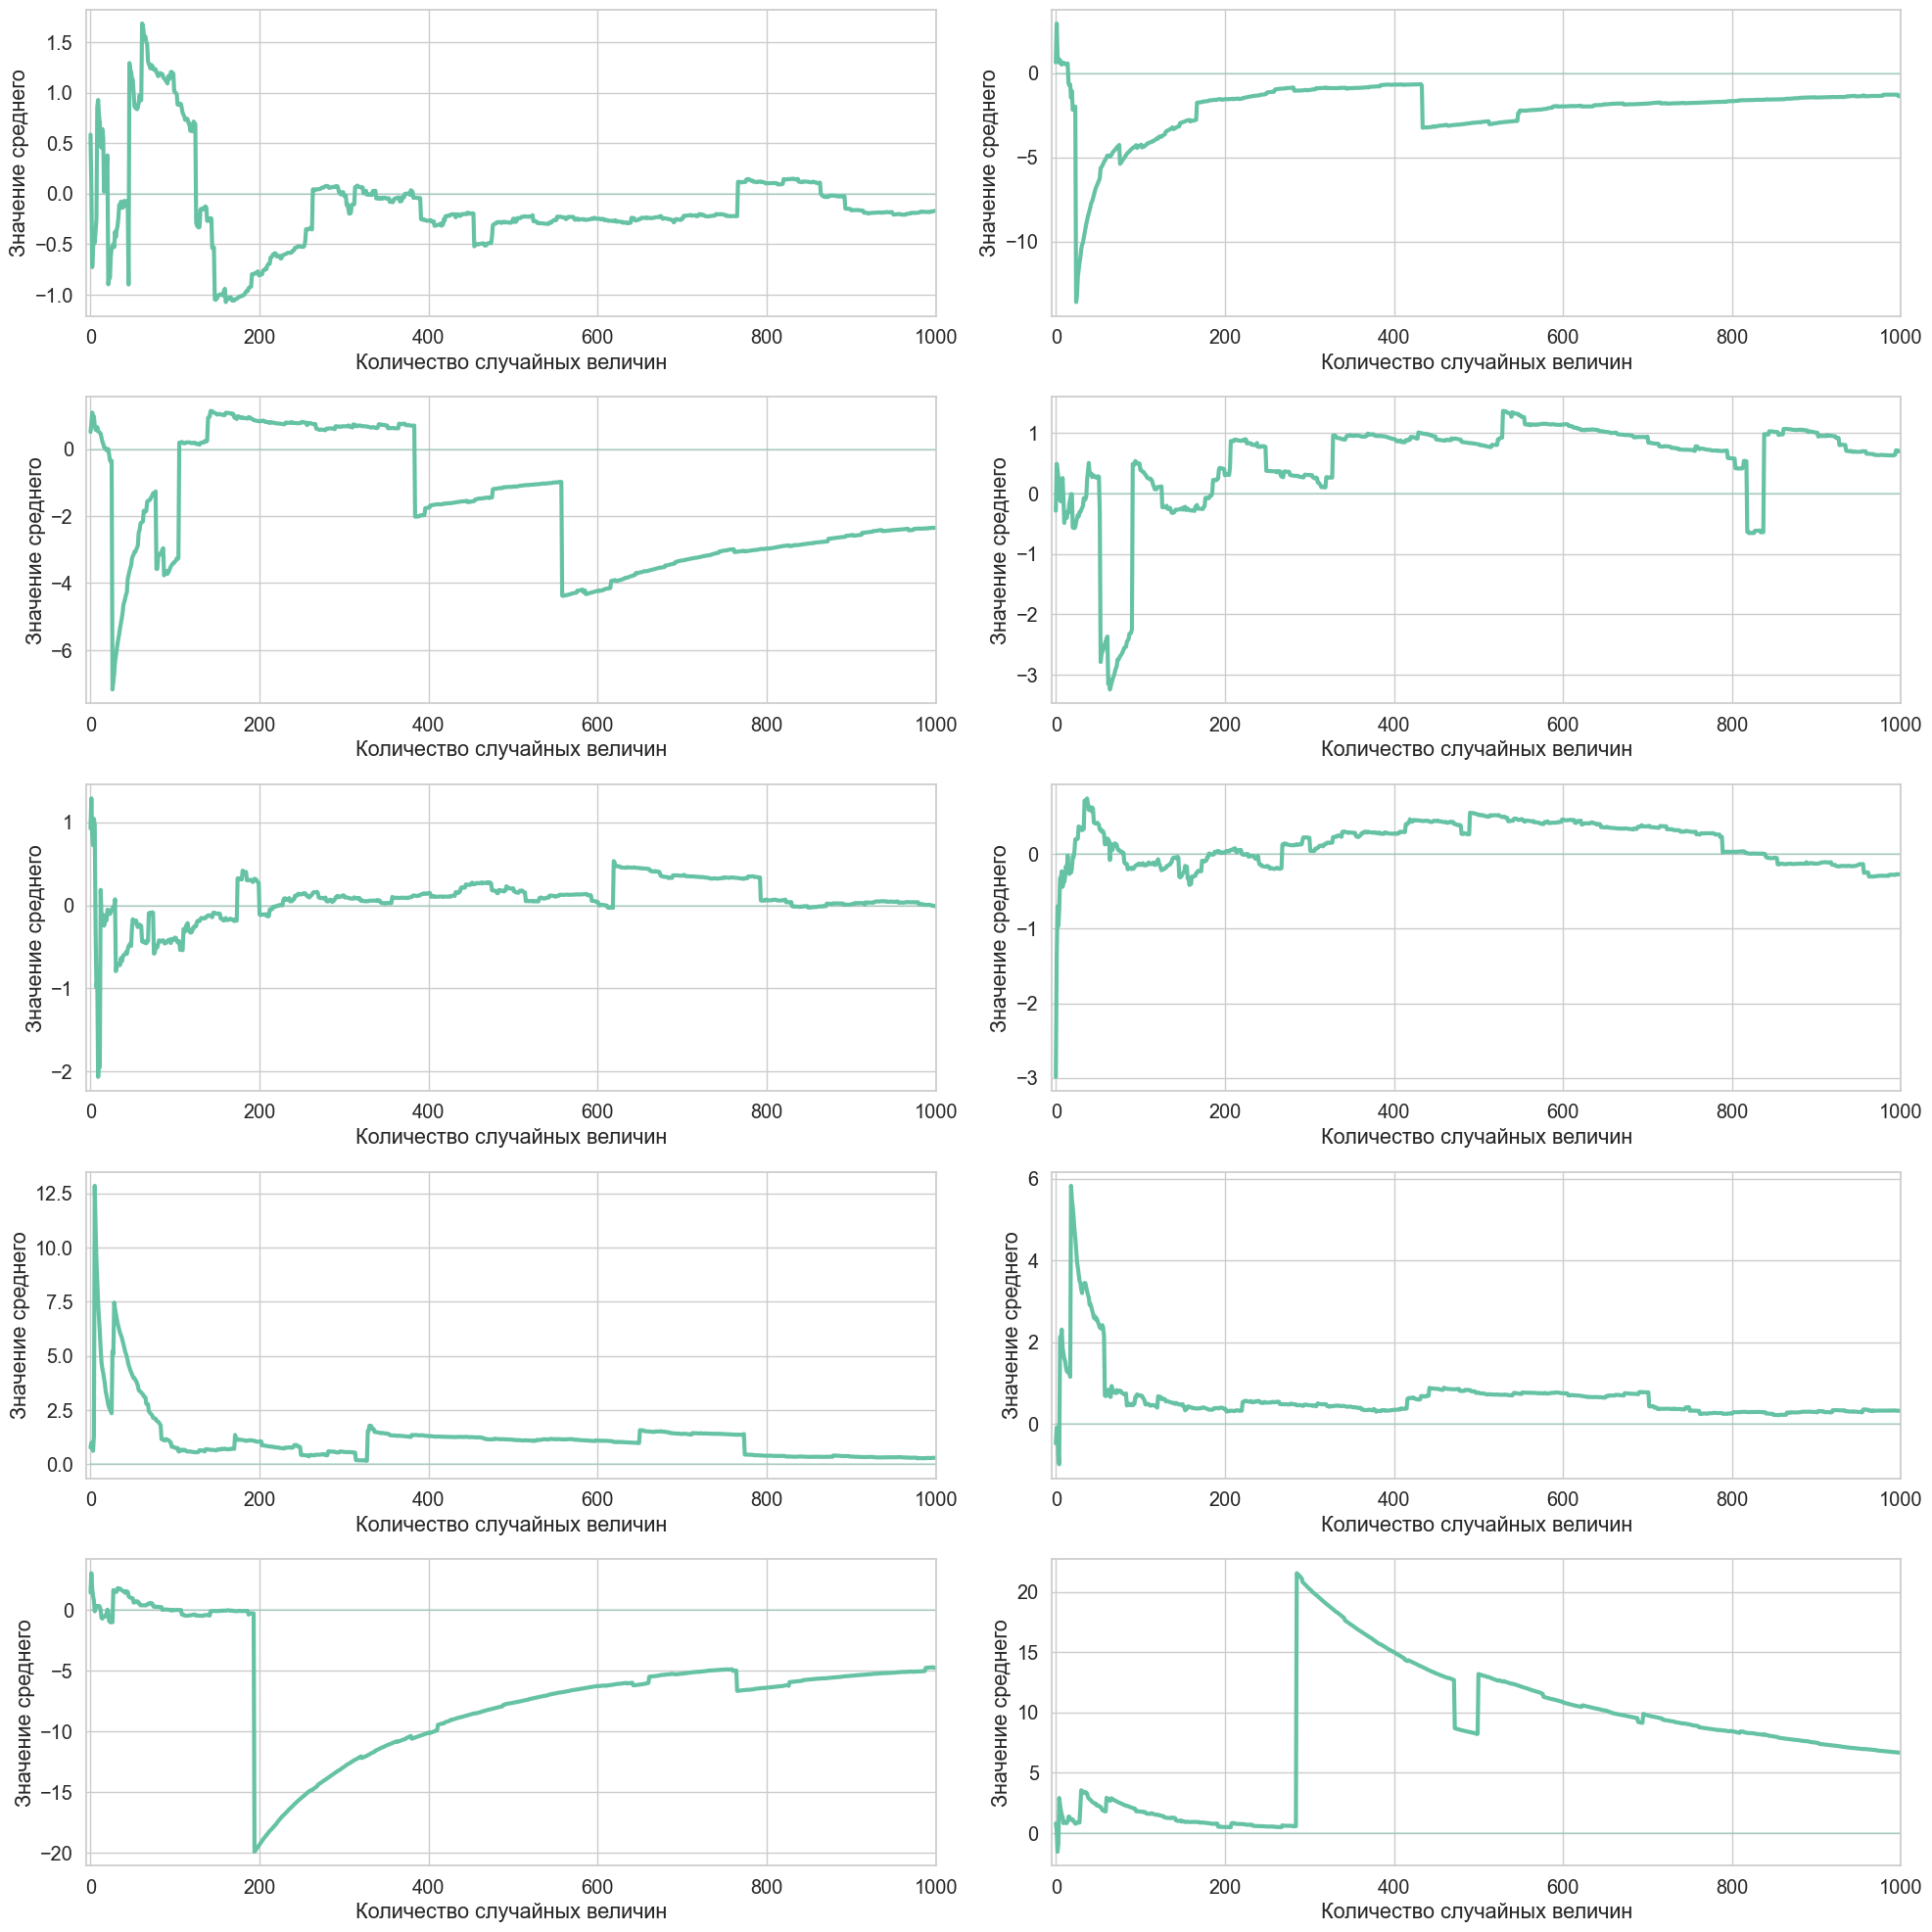

In [ ]:
size = 1000

plt.figure(figsize=(20, 20))

for i in range(10):
    samples = sps.cauchy(0, 1).rvs(size=size)
    cum_means = samples.cumsum() / (np.arange(size) + 1)

    plt.subplot(5, 2, i + 1)
    plt.plot(cum_means, lw=3)
    plt.hlines(0, 0, size, alpha=0.3)
    plt.xlabel("Количество случайных величин")
    plt.ylabel("Значение среднего")
    plt.xlim((-5, size))

plt.tight_layout()

Сложно понять выполняется ли ЗБЧ. В целом среднее обычно убывает, но иногдна сильно подскакивает. Мне кажется ЗБЧ выполняется, просто для сходимости нужно большее количетво величин, чем для примера с занятия.

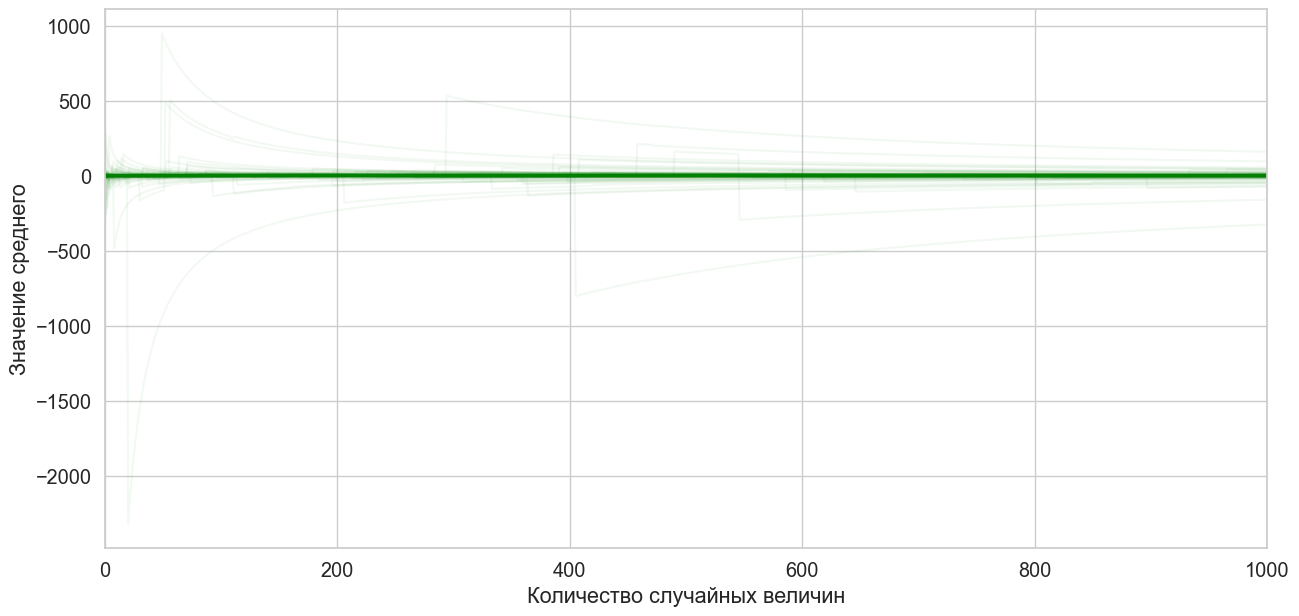

In [ ]:
size = 1000
samples_count = 500

samples = sps.cauchy(0, 1).rvs(size=(samples_count, size))
cum_means = samples.cumsum(axis=1) / (np.arange(size) + 1)

plt.figure(figsize=(15, 7))

for i in range(samples_count):
    plt.plot(np.arange(size) + 1, cum_means[i], color="green", alpha=0.05)
plt.xlabel("Количество случайных величин")
plt.ylabel("Значение среднего")
plt.xlim((0, size));

На этом графике ничего не понятно, я его приближу.

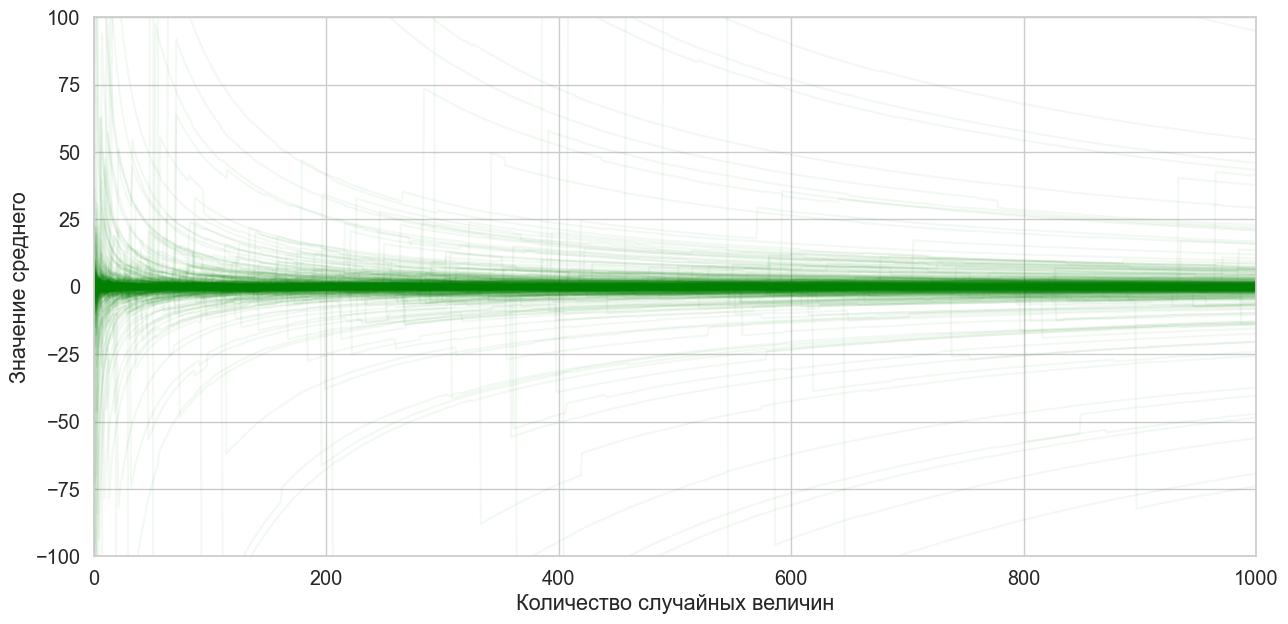

In [ ]:
plt.figure(figsize=(15, 7))

for i in range(samples_count):
    plt.plot(np.arange(size) + 1, cum_means[i], color="green", alpha=0.05)

plt.xlabel("Количество случайных величин")
plt.ylabel("Значение среднего")
plt.xlim((0, size));
plt.ylim(-100, 100);

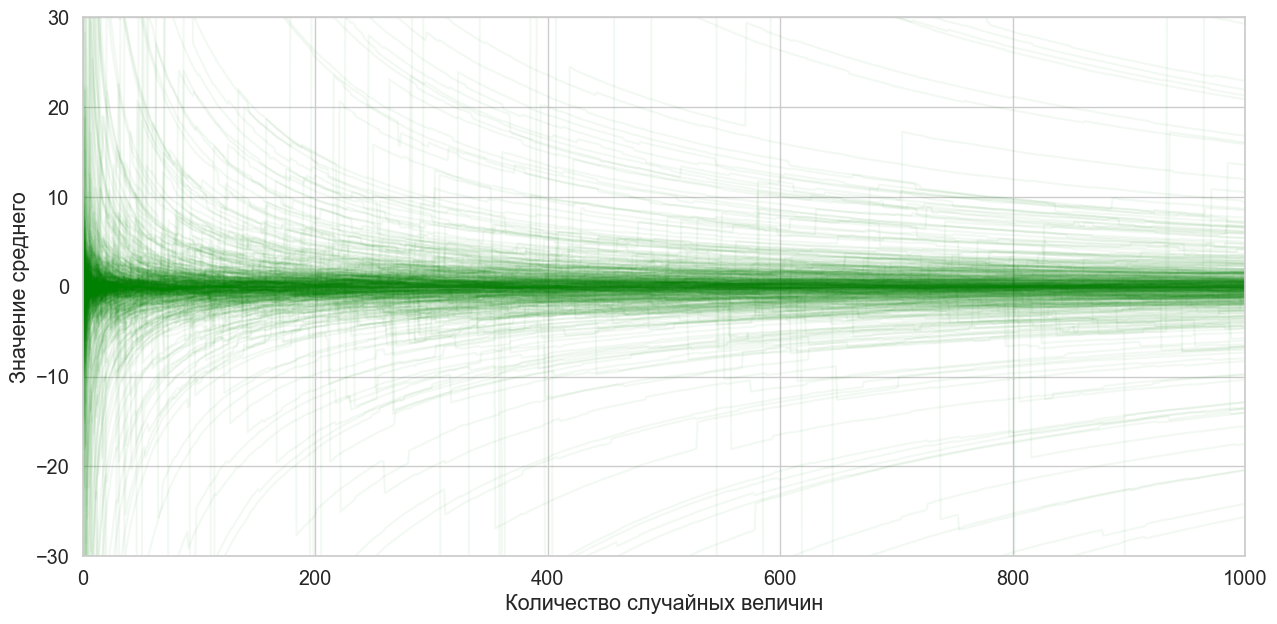

In [ ]:
plt.figure(figsize=(15, 7))

for i in range(samples_count):
    plt.plot(np.arange(size) + 1, cum_means[i], color="green", alpha=0.05)

plt.xlabel("Количество случайных величин")
plt.ylabel("Значение среднего")
plt.xlim((0, size));
plt.ylim(-30, 30);

Аналогичным образом проведите эксперимент по изучению зависимости *выборочной* медианы от размера выборки.

In [73]:
cum_medians = np.zeros_like(samples)

for i in range(1, size + 1):
    cum_medians[:, i - 1] = np.median(samples[:, :i], axis=1)

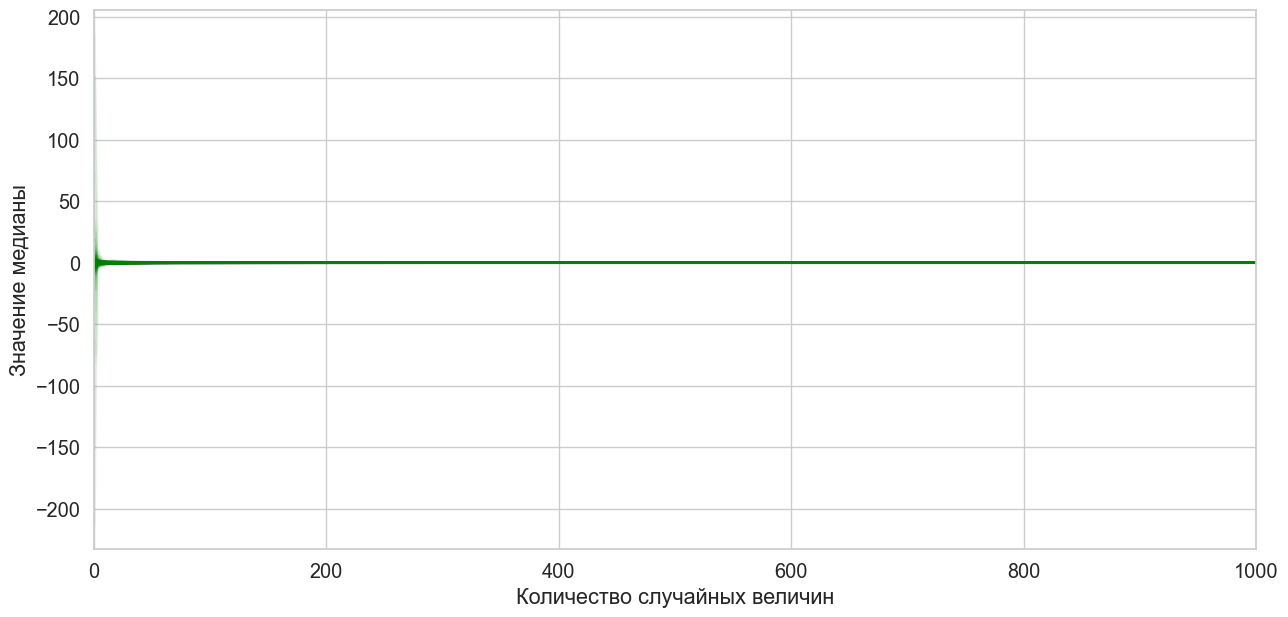

In [74]:
plt.figure(figsize=(15, 7))

# рисуем для каждой выборки отдельно
for i in range(samples_count):
    plt.plot(np.arange(size) + 1, cum_medians[i], color="green", alpha=0.05)

plt.xlabel("Количество случайных величин")
plt.ylabel("Значение медианы")
plt.xlim((0, size));

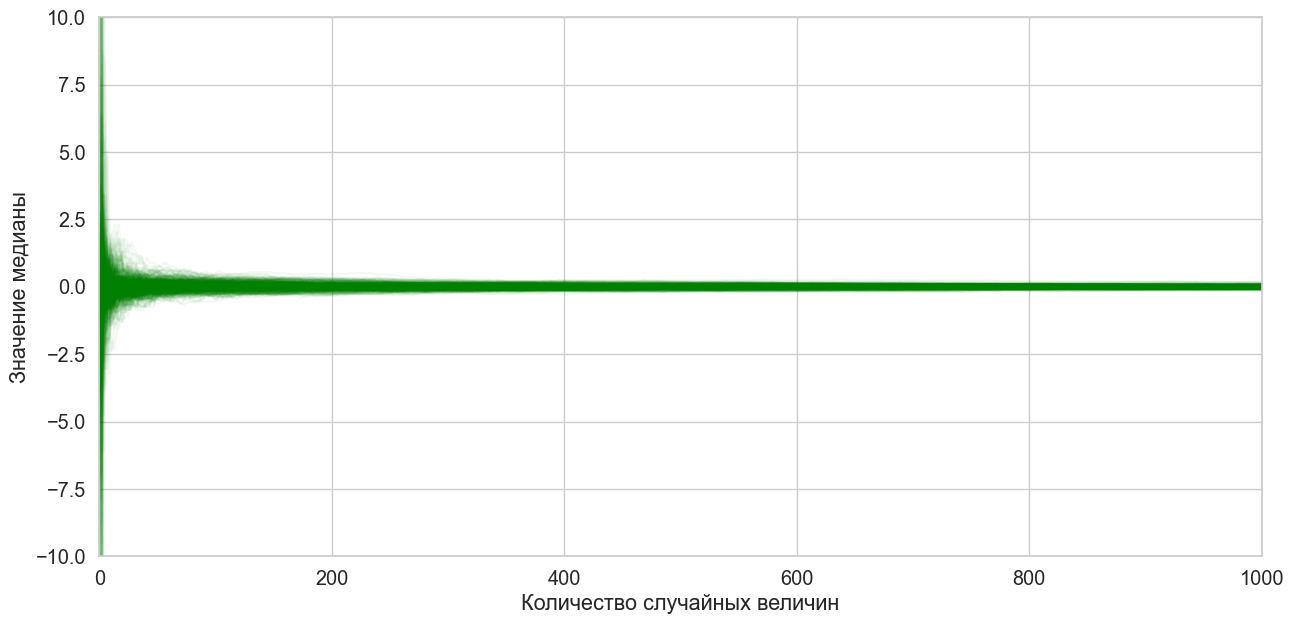

In [77]:
plt.figure(figsize=(15, 7))

for i in range(samples_count):
    plt.plot(np.arange(size) + 1, cum_medians[i], color="green", alpha=0.05)

plt.xlabel("Количество случайных величин")
plt.ylabel("Значение медианы")
plt.xlim((0, size));
plt.ylim(-10, 10);

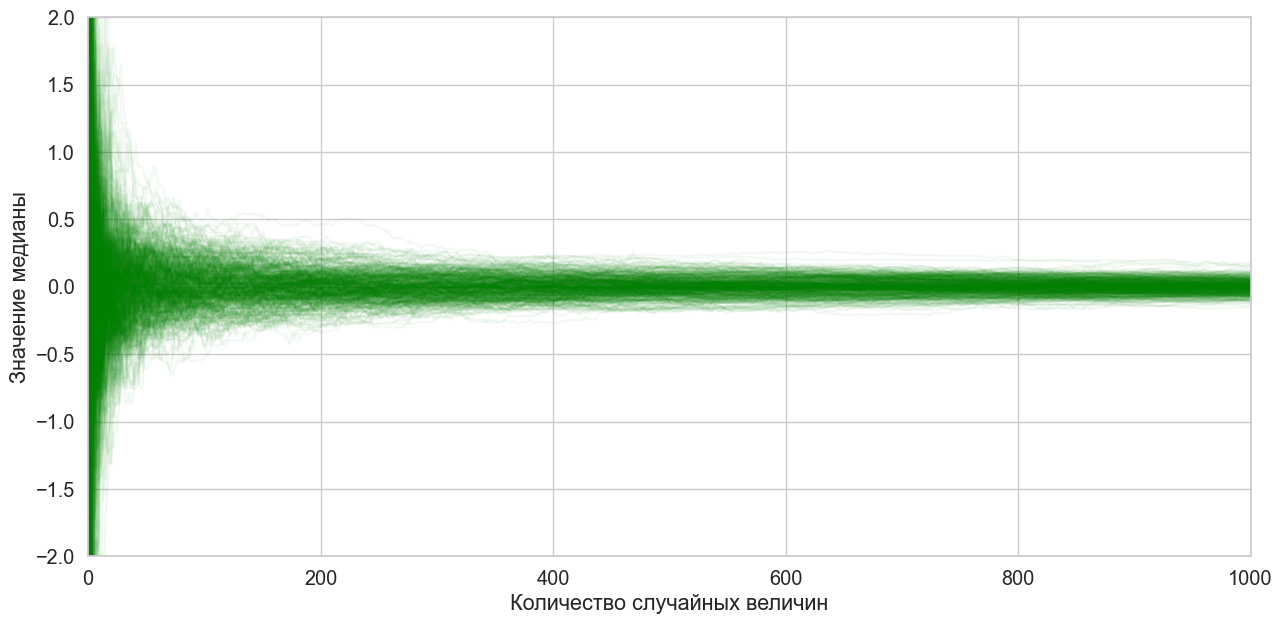

In [80]:
plt.figure(figsize=(15, 7))

for i in range(samples_count):
    plt.plot(np.arange(size) + 1, cum_medians[i], color="green", alpha=0.05)

plt.xlabel("Количество случайных величин")
plt.ylabel("Значение медианы")
plt.xlim((0, size));
plt.ylim(-2, 2);

Для Exp ЗБЧ выполняется, но для сходимости среднего нужно довольно много случайных величин. А для медианы сходимость гораздо быстрее. Это происходит из-за того что у эксп. рапределения с не очень маленькой вероятностью значение с.в. может быть довольно большой или маленькой.

---

На практике не редко возникает вопрос &mdash; **сколько времени потребуется на сбор данных, чтобы оценить среднее с достаточной точностью**.
Возьмем в качестве меры отклонения от среднего *среднее значение модуля отклонения от среднего*.

Рассмотрим распределения $Bern(a)$ для $a=0.5$. Пусть для нас допустимо отклонение на 0.02.
Реализуйте данный эксперимен для $K=500$  и найдите значение $n$. Визуализируйте зависимость $F(n)$ от $n$.

In [ ]:
K = 500
max_n = 1000
true_mean = 0.5
threshold = 0.02

samples = np.random.binomial(1, true_mean, size=(K, max_n)) 

cumsum = np.cumsum(samples, axis=1)
n_values = np.arange(1, max_n + 1)
cummeans = cumsum / n_values

deviations = np.abs(cummeans - true_mean)
F_n = deviations.mean(axis=0)

min_n = np.argmax(F_n <= threshold) + 1
print(f"Минимальное n, при котором F(n) <= 0.02: {min_n}")

Минимальное n, при котором F(n) <= 0.02: 354


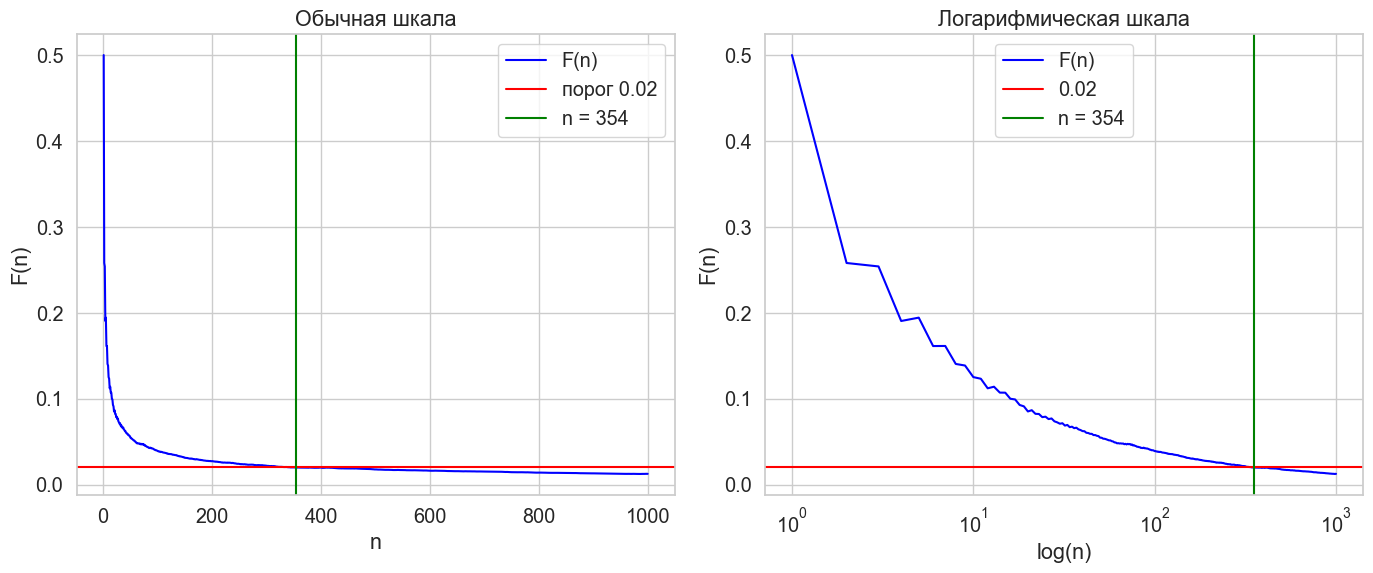

In [104]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(n_values, F_n, label="F(n)", color='blue')
plt.axhline(threshold, color='red', label="порог 0.02")
plt.axvline(min_n, color='green', label=f"n = {min_n}")
plt.xlabel("n")
plt.ylabel("F(n)")
plt.title("Обычная шкала")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(n_values, F_n, label="F(n)", color='blue')
plt.axhline(threshold, color='red', label="0.02")
plt.axvline(min_n, color='green', label=f"n = {min_n}")
plt.xlabel("log(n)")
plt.xscale('log')
plt.ylabel("F(n)")
plt.title("Логарифмическая шкала")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


Повторите данный эксперимент для значений $a$ от 0.05 до 0.95 с шагом 0.05. Визуализируйте зависимость необходимого размера выборки $n$ от значения $a$.

In [ ]:
a_values = np.arange(0.05, 1.00, 0.05)
required_ns = []

for a in a_values:
    samples = sps.bernoulli(a).rvs(size=(K, max_n))

    cumulative_sums = samples.cumsum(axis=1)
    n_range = np.arange(1, max_n + 1)
    means = cumulative_sums / n_range

    deviations = np.abs(means - a)
    F_n = deviations.mean(axis=0)
    suitable_n = np.argmax(F_n <= threshold)
    required_ns.append(suitable_n + 1)


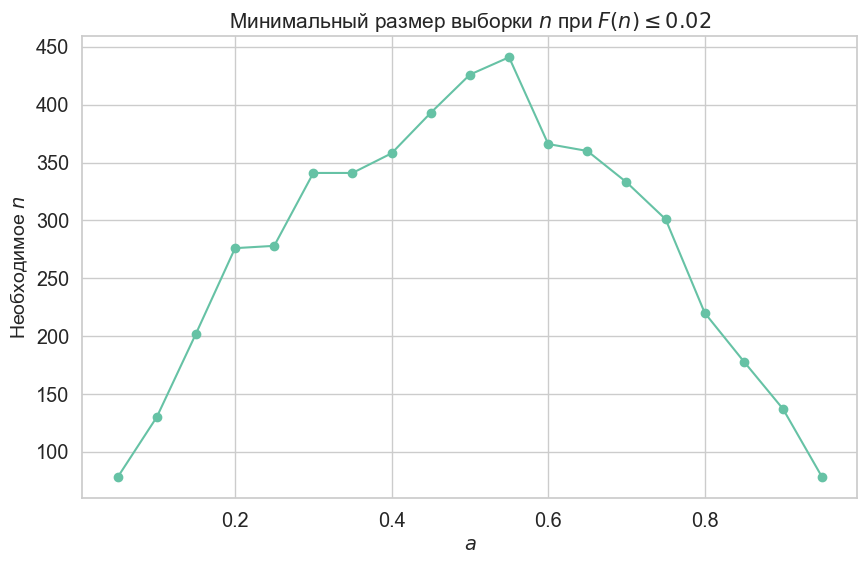

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(a_values, required_ns, marker='o')
plt.xlabel('$a$', fontsize=14)
plt.ylabel('Необходимое $n$', fontsize=14) 
plt.title('Минимальный размер выборки$', fontsize=15)
plt.grid(True)
plt.show()

Значение целевой функции при росте количества случайных величин убывает довольно быстро на маленьких значениях (даже быстрее чем экспонента), но со временем скорость убывания сокращается. В какой-то момент перестает иметь смысл увеличивать количество экспериментов, потому что функция практически стабилизируется.  
Необходимое количество случайных величин меньше всего для значений a близких к 0 или 1. График примерно симметричный, максимум в ~0,5 Это звучит согласовано с теорией, потому что дисперсия Bern равна $a(1-a)$. Если полставить разные параметры в дисперсию, то получится парабола с ветвями вниз и максимумом в 0,5. 

---

Рассмотрим следующее вероятностное пространство:
* $\Omega = \{1, 2, 3, 4, 5, 6, 7, 8\}$ – номера точек на единичной окружности.

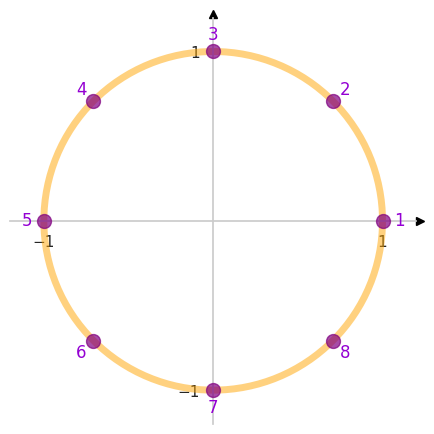
* $\sigma$-алгебра $\mathscr{F} = 2^{\{1, 2, 3, 4, 5, 6, 7, 8\}}$
* $\mathsf{P}$ - равномерное распределение:
$$
\mathsf{P}(\omega = \{k\}) = \frac{1}{8}, \quad k = 1, 2, \ldots, 8.
$$

Определим случайную величину следующим образом:
$$
X(\omega) = \sin\left(\frac{2\pi (\omega - 1)}{8}\right) = \sin\left(\frac{\pi (\omega - 1)}{4}\right)$$

Пусть случайная величина $Y$ определяется следующим образом:
$$ Y(\omega) = \begin{cases}
1, & \text{если } \sin\left(\frac{\pi (\omega - 1)}{4}\right) \geq 0, \\
0, & \text{иначе.}
\end{cases} $$


Какому наблюдению соответствует случайная величина $Y$?

Находится ли точка в верхней половине окружности.



Найдите:
* Условное распределение $X|Y$;
* Условное математическое ожидание $\mathsf{E}(X|Y=1)$;
* Условное математическое ожидание $\mathsf{E}(X|Y=0)$.

Визуализируйте условное распределение $X|Y$.

Найдем распределения:
  
$\mathbb{P}(Y = 1) = \frac{5}{8}$  
$\mathbb{P}(Y = 1) = \frac{3}{8}$  

$\mathbb{P}(\omega = k \mid Y = 1) = \frac{\mathbb{P}(\omega = k)}{\mathbb{P}(Y = 1)} = \frac{\frac{1}{8}}{\frac{5}{8}} = \frac{1}{5}$ для $k = 1, \dots, 5$  
$\mathbb{P}(\omega = k \mid Y = 1) = 0$ для $k = 6, 7, 8$  

$\mathbb{P}(\omega = k \mid Y = 0) = \frac{\mathbb{P}(\omega = k)}{\mathbb{P}(Y = 0)} = \frac{\frac{1}{8}}{\frac{3}{8}} = \frac{1}{3}$ для $k = 6, 7, 8$  
$\mathbb{P}(\omega = k \mid Y = 0) = 0$ для $k = 1, \dots, 5$  

$
\mathbb{P}(\omega = k \mid Y = 1) =
\begin{cases}
\frac{1}{5}, & k = 1, 2, 3, 4, 5 \\
0, & \text{иначе}
\end{cases}
$  
$
\mathbb{P}(\omega = k \mid Y = 0) =
\begin{cases}
\frac{1}{3}, & k = 6, 7, 8 \\
0, & \text{иначе}
\end{cases}
$

Условные матожи:

$\mathbb{E}(\omega \mid Y = 1) = \sum_{k=1}^{5} k \cdot \frac{1}{5} = \frac{1 + 2 + 3 + 4 + 5}{5} = \frac{15}{5} = 3$  
$\mathbb{E}[\omega \mid Y = 0] = \sum_{k=6}^{8} k \cdot \frac{1}{3} = \frac{6 + 7 + 8}{3} = \frac{21}{3} = 7$

In [120]:
omega = np.arange(1, 9)
Y = np.array([1 if np.sin(np.pi * (w - 1) / 4) >= 0 else 0 for w in omega])
mask_Y1 = Y == 1
mask_Y0 = Y == 0

E_omega_Y1 = np.mean(omega[mask_Y1])
E_omega_Y0 = np.mean(omega[mask_Y0])


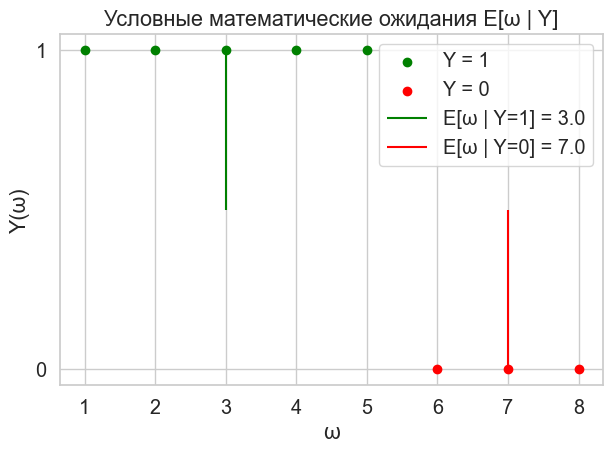

In [122]:
plt.scatter(omega[mask_Y1], Y[mask_Y1], color='green', label='Y = 1')
plt.scatter(omega[mask_Y0], Y[mask_Y0], color='red', label='Y = 0')
plt.vlines(E_omega_Y1, ymin=0.5, ymax=1, color='green', label=f'E[ω | Y=1] = {E_omega_Y1:.1f}')
plt.vlines(E_omega_Y0, ymin=0, ymax=0.5, color='red', label=f'E[ω | Y=0] = {E_omega_Y0:.1f}')
plt.xticks(omega)
plt.yticks([0, 1])
plt.xlabel('ω')
plt.ylabel('Y(ω)')
plt.title('Условные математические ожидания E[ω | Y]')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()